In [67]:
from typing import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

In [68]:
class State(TypedDict):
    """
    A class representing a state in the state graph.
    """
    marks: int
    iteration: int

In [69]:
graph = StateGraph(State)

In [70]:
def check_marks(state: State) -> State:
    print(f"Marks = {state['marks']}, Iteration = {state['iteration']}")
    return state

In [71]:
def increase_marks(state: State) -> State:
    """
    A function to increase the marks by 5.
    """
    marks = state["marks"] + 5
    return {"marks": marks, "iteration": state["iteration"] + 1}

In [72]:
def should_continue(state: State):
    """
    A function to determine if the loop should continue based on the marks.
    """
    if state["marks"] < 40:
        return "increase_marks"    
    return END

In [73]:
graph = StateGraph(State)

graph.add_node("check_marks", check_marks)
graph.add_node("increase_marks", increase_marks)

graph.add_edge(START, "check_marks")

graph.add_conditional_edges(
    "check_marks",
    should_continue,
    {
        "increase_marks": "increase_marks",
        END: END,
    },
)

graph.add_edge("increase_marks", "check_marks")

workflow = graph.compile()

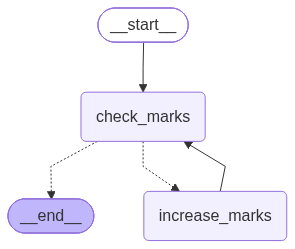

In [74]:
workflow

In [75]:
result = workflow.invoke(
    {
        "marks": 25,
        "iteration": 0
    }
)

Marks = 25, Iteration = 0
Marks = 30, Iteration = 1
Marks = 35, Iteration = 2
Marks = 40, Iteration = 3
